# Imports

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os

import numpy as np
from matplotlib import pyplot as plt

# Data

In [ ]:
%%time
import sys

sys.path.append("../utils")

CPU times: total: 0 ns
Wall time: 86.1 μs


In [ ]:
%%time
import data_2p_loader as data_loader


df_rois, df_fields, df_outline = data_loader.load_all_dfs()
df = data_loader.load_df_rois_morph(df_rois=df_rois)

Restoring numpy arrays in column: ch0_average
Restoring numpy arrays in column: ch1_average
Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: ch0_average
Restoring numpy arrays in column: ch1_average
Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: ch0_average
Restoring numpy arrays in column: ch1_average
Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: ch0_average
Restoring numpy arrays i

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\joesterle\\github\\eyewire2\\eyewire2-figures\\utils\\..\\data\\spreadsheets\\Eyewire II Proofread Cells Main List - All Cells 2026-07-03.csv'

In [ ]:
%%time
import data_io

config = data_io.get_data_config()
data_root = config.get("root")

CPU times: total: 0 ns
Wall time: 1.01 ms


In [ ]:
df_sacs = df[df['Cell Type'] == 'ON SAC'].copy()

In [ ]:
# All confirmed as "both_strong"
print(df.loc[df['Cell Type'] == 'ON SAC', 'Latest NucID'].values)

['720575940554861467' '720575940572981949' '720575940554891618'
 '720575940549337669' '720575940562142291' '720575940564970437'
 '720575940571151305' '720575940548246106' '720575940555967902'
 '720575940558155214' '720575940555522718' '720575940553551833'
 '720575940568025878' '720575940555439536' '720575940570979195'
 '720575940537107413' '720575940574185157' '720575940572045509'
 '720575940546942120' '720575940547320922' '720575940549419201'
 '720575940574320317' '720575940552342151' '720575940552302922'
 '720575940576233020' '720575940559439597' '720575940562768302'
 '720575940563803054' '720575940540113546' '720575940575963708'
 '720575940555336314' '720575940556938831' '720575940567903497'
 '720575940569769505' '720575940546191816' '720575940555652497'
 '720575940562304852' '720575940560823636' '720575940568637961'
 '720575940557918517' '720575940554089645' '720575940554091181'
 '720575940564489822' '720575940531612083' '720575940551443458'
 '720575940562362812' '72057594056369528

In [ ]:
for field, df_field in df_sacs.groupby('field'):
    print(field)
    print(np.sort(df_field['Latest SegID'].values.astype(int)))

GCL0
[720575940545899781 720575940550011106 720575940552838981
 720575940553211973 720575940556421607 720575940557921829
 720575940559558491 720575940559774600 720575940565165807
 720575940568587602 720575940573246525 720575940574437705
 720575940574791163 720575940581510152]
GCL1
[720575940547940040 720575940549776224 720575940553935194
 720575940555645155 720575940558682534 720575940562796239
 720575940563145273 720575940565329821 720575940569689625
 720575940578433226]
GCL2
[720575940545311219 720575940556765443 720575940559897418
 720575940567191371 720575940570202393 720575940570227253
 720575940579052746 720575940585113878]
GCL3
[720575940554749466 720575940556288487 720575940557237750
 720575940560480997 720575940563685101 720575940566361822
 720575940568381112 720575940570574881]
GCL4
[720575940551719027 720575940554439194 720575940557124706
 720575940560424382 720575940566539482 720575940567200587
 720575940569675536 720575940573708617 720575940573958960
 720575940573959984 72

In [ ]:
# Version in Overleaf
# GCL0
# [720575940572885792 720575940566710278 720575940559774600
#  720575940562511187 720575940557921829 720575940561027498
#  720575940565165807 720575940559558491 720575940545899781
#  720575940552838981 720575940581510152 720575940576356549
#  720575940569052267 720575940556421607]
# GCL1
# [720575940545926661 720575940572328807 720575940578433226
#  720575940558682534 720575940558094727 720575940563145273
#  720575940547940040 720575940549776224 720575940562796239
#  720575940569689625]
# GCL2
# [720575940579256464 720575940553426083 720575940570227253
#  720575940556765443 720575940567191371 720575940585113878
#  720575940554919918 720575940545311219]
# GCL3
# [720575940568381112 720575940556288487 720575940554749466
#  720575940567864205 720575940567518130 720575940563685101
#  720575940563685101 720575940569910418 720575940570574881]
# GCL4
# [720575940559596123 720575940573708617 720575940553072535
#  720575940567200587 720575940566539482 720575940557124706
#  720575940573958960 720575940560424382 720575940554439194
#  720575940551719027 720575940573959984]

# Plot

In [ ]:
%%time
from style import set_rc_params

set_rc_params()

CPU times: total: 0 ns
Wall time: 2.36 ms


In [ ]:
%%time
fig_dir = f'../figures/calcium_data'
os.makedirs(fig_dir, exist_ok=True)

CPU times: total: 0 ns
Wall time: 312 μs


In [ ]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

    ax.axis('off')

In [ ]:
def plot_traces(ax, traces, time, dy=-1.5, **kwargs):
    for i, trace in enumerate(traces):
        offset = i * dy
        ax.plot(time, trace + offset, **kwargs)

In [ ]:
from scipy import ndimage

def downsample_uniform_filter(data, n):
    """Downsample using uniform filter - works with any array size"""
    filtered = ndimage.uniform_filter1d(data, size=n, axis=1)
    return filtered[:, ::n]

In [ ]:
chirp_stimulus = np.load(os.path.join(data_root, "chirp_stimulus.npy"))

Field 0: VD-dist_um=88.04599999999999
Field 1: VD-dist_um=74.47799999999995
Field 2: VD-dist_um=74.54700000000003
Field 3: VD-dist_um=64.43499999999995
Field 4: VD-dist_um=78.90599999999995


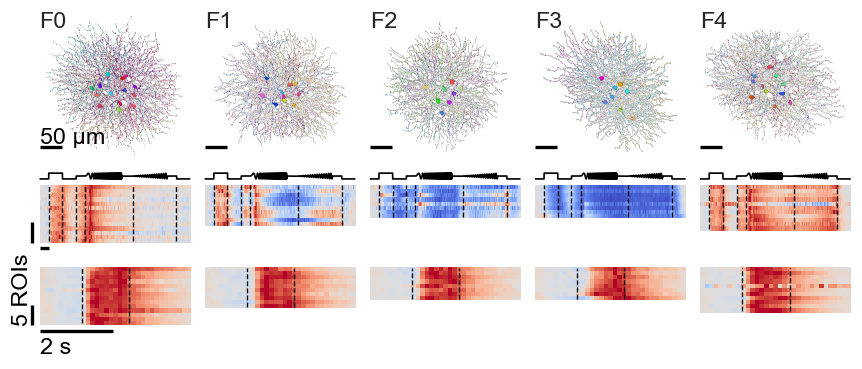

In [ ]:
cmap = 'coolwarm'

fig, axs = plt.subplots(3, 5, figsize=(7, 3), height_ratios=(2, 1, 1), sharey='row')

for ax in axs.flat:
    ax.axis('off')

#fig.suptitle('All ON SACs in 2p fields', fontsize=14)
plt.tight_layout(h_pad=0)

nmax = 14
size_full_um = 343

for i in range(5):
    ax = axs[0, i]
    png_path = os.path.join(
        data_root,
        "em-fields",
        f"sacs{i}.png"
    )
    img = plt.imread(png_path)
    ax.imshow(img, extent=(0, 1, 0, 1))
    ax.axis('off')
    ax.text(0, 1, f"F{i}", fontsize=14, ha='left', va='top')
    ax.plot([0, 50 / 343], [+.1] * 2, c='k', solid_capstyle='butt', lw=2, clip_on=False)
    if i == 0:
        ax.text(0, 0.1, '50 µm', c='k', ha='left', rotation=0, va='bottom', fontsize=14)

    df_field = df_sacs[df_sacs.field == f'GCL{i}']
    print(f"Field {i}: VD-dist_um={(df_field.ventral_dorsal_pos_um.max() - df_field.ventral_dorsal_pos_um.min())}")

    t_chirp = np.arange(df_field.chirp_average_norm.iloc[0].size) * df_field.chirp_average_dt.iloc[0]
    t_bar = np.arange(df_field.bar_time_component.iloc[0].size) * df_field.bar_snippets_dt.iloc[0]

    chirps = np.vstack(df_field.chirp_average_norm)
    im_chirps = np.full((14, chirps.shape[1]), np.nan)
    im_chirps[:chirps.shape[0], :] = chirps
    im_chirps = downsample_uniform_filter(im_chirps, n=4)

    ax = axs[1, i]
    ax.plot(np.linspace(t_chirp[0], t_chirp[-1], len(chirp_stimulus)),
            1.1 + 0.1 * chirp_stimulus / np.max(chirp_stimulus), c='k', clip_on=False, lw=1, solid_capstyle='butt')
    ax.set_xlim(t_chirp[0], t_chirp[-1])

    ax.imshow(im_chirps, vmin=-1, vmax=+1, aspect='auto', extent=(t_chirp[0], t_chirp[-1], 0, 1), cmap=cmap,
              interpolation='none')
    ax.set_xlim(t_chirp[0], t_chirp[-1])
    for t in [2, 5, 8, 10, 20.5, 30]:
        ax.plot([t, t], [1 - (chirps.shape[0] / (nmax + 0.5)), 1], c='k', lw=0.8, ls='--')

    if i == 0:
        ax.plot([0, 2], [-.1, -.1], c='k', solid_capstyle='butt', lw=2, clip_on=False)
        ax.plot([-0.05 * t_chirp[-1]] * 2, [0, 5 / nmax], c='k', solid_capstyle='butt', lw=2, clip_on=False)

    ax = axs[2, i]
    bars = np.vstack(df_field.bar_time_component)
    im_bars = np.full((nmax, bars.shape[1]), np.nan)
    im_bars[:bars.shape[0], :] = bars

    ax.plot([t_bar[0], t_bar[-1]], 1.1 + 0.1 * np.array([0, 1]), c=(1, 1, 1, 0), clip_on=False, lw=1,
            solid_capstyle='butt')
    ax.imshow(im_bars, vmin=-1, vmax=+1, aspect='auto', extent=(t_bar[0], t_bar[-1], 0, 1), cmap=cmap,
              interpolation='none')
    ax.set_xlim(t_bar[0], t_bar[-1])
    for t in [1.152, 2.432]:
        ax.plot([t, t], [1 - (chirps.shape[0] / (nmax + 0.5)), 1], c='k', lw=0.8, ls='--')

    if i == 0:
        ax.plot([0, 2], [-.1, -.1], c='k', solid_capstyle='butt', lw=2, clip_on=False)
        ax.text(0, -0.2, '2 s', c='k', ha='left', rotation=0, va='top', fontsize=14)
        ax.plot([-0.05 * t_bar[-1]] * 2, [0, 5 / nmax], c='k', solid_capstyle='butt', lw=2, clip_on=False)
        ax.text(-0.05 * t_bar[-1], 0, f'5 ROIs', c='k', ha='right', rotation=90, va='bottom', fontsize=14)

plt.savefig(f'{fig_dir}/ON_SACs.svg', bbox_inches='tight', dpi=600, transparent=True)